<a href="https://colab.research.google.com/github/ahmed8809/FlyRank_intern/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN {HF_TOKEN})"
)

rel = "hf://datasets/FlyRank/internship-warehouse"

print("Connection ready")

Connection ready


# 1. Method choice and why

## Method: K-Means clustering

My lane is **Structured Content Archetype Clustering**, with the question:

> What performance archetypes exist across the content inventory?

I will use **K-Means clustering** because this is an unsupervised question: there is no target label that I need to predict. Instead, I want to discover recurring groups of content that behave similarly according to structured warehouse signals.

K-Means fits this task because:

- it groups pages according to their similarity across numeric features;
- it is straightforward to explain and inspect;
- the features can be standardized so that different measurement scales do not cause one feature to dominate;
- candidate values of `k` can be compared using the silhouette score;
- cluster profiles can be inspected using interpretable statistics before assigning archetype names.

The clustering features will be based on safe structured signals available in the warehouse, such as:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_ctr`
- `gsc_avg_position`
- `stale_days`
- `position_missing`

Identifiers such as `client_hash_id` and `content_hash_id` will be used only to identify and join records, not as model features.

I will use **PCA only to visualize** the resulting clusters in two dimensions. It will not be used as the clustering method.

### Important limitation

This is **structured performance clustering, not semantic clustering**. The warehouse release does not contain article text, so the resulting groups describe recurring performance/freshness behavior rather than the semantic meaning or topic of the content.

I will inspect the cluster profiles before naming the archetypes rather than assigning names in advance.

# 2. Split design

## Data snapshot

I will use the **March 2026** warehouse partition as the modeling snapshot.

This keeps the analysis away from the final June 2026 month, which is treated as a sealed outcome month in the internship data workflow.

The unit being clustered will be a **content item within a client**, represented by:

- `client_hash_id`
- `content_hash_id`

The client identifier is used for grouping and validation only; it is not used as a clustering feature.

## Validation design

Because K-Means is unsupervised, there is no target variable and therefore no conventional supervised train/test accuracy split.

Instead, I will use a **client-grouped split** to check the stability of the discovered structure:

- pages from a client stay in the same split;
- the split is fixed with a random seed for reproducibility;
- no client identifier is given to K-Means as a feature;
- cluster quality will be assessed using the silhouette score and by comparing cluster profiles across the grouped data.

This is more honest than randomly splitting individual pages, because pages belonging to the same client can share characteristics. A random page-level split could therefore make the validation sets look more independent than they really are.

## Comparison with the Week-4 baseline

The Week-4 baseline will be evaluated on the **same March 2026 content population** used for the clustering analysis.

The baseline comparison will use the same client grouping rather than comparing results from a different month or population.

Since K-Means is unsupervised, I will not report a fake classification accuracy. The comparison will instead focus on whether the discovered archetypes provide a useful and interpretable grouping of the same content population that the Week-4 baseline acted on.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### 3.1 Build the March 2026 content-level feature dataset

The warehouse fact table is daily, so I aggregate March 2026 to one row per
`client_hash_id × content_hash_id`.

Only information available in the March snapshot is used. Identifiers are
retained for grouping and interpretation but are not used as clustering features.

The clustering features are:

1. `gsc_impressions` — total March Search Console impressions
2. `gsc_clicks` — total March Search Console clicks
3. `gsc_ctr` — clicks divided by impressions
4. `gsc_avg_position` — average observed search position
5. `stale_days` — days since the content was last updated at the March snapshot
6. `position_missing` — whether Search Console average position was unavailable

In [2]:
march_features = con.sql(f"""
WITH march AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(COALESCE(f.gsc_impressions, 0)) AS gsc_impressions,
        SUM(COALESCE(f.gsc_clicks, 0)) AS gsc_clicks,

        AVG(f.gsc_avg_position) AS gsc_avg_position,

        MAX(f.report_date) AS snapshot_date,

        MAX(
            CASE
                WHEN f.gsc_avg_position IS NULL THEN 1
                ELSE 0
            END
        ) AS position_missing

    FROM read_parquet(
        '{rel}/fact_content_daily_performance/month=2026-03/*.parquet'
    ) f

    WHERE f.gsc_data_available IS TRUE

    GROUP BY
        f.client_hash_id,
        f.content_hash_id
),

content AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date

    FROM read_parquet(
        '{rel}/dim_content.parquet'
    )
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.gsc_impressions,
    m.gsc_clicks,

    CASE
        WHEN m.gsc_impressions > 0
        THEN m.gsc_clicks::DOUBLE / m.gsc_impressions
        ELSE 0
    END AS gsc_ctr,

    m.gsc_avg_position,
    m.position_missing,

    DATE_DIFF(
        'day',
        c.content_updated_date,
        m.snapshot_date
    ) AS stale_days

FROM march m

INNER JOIN content c
    ON m.client_hash_id = c.client_hash_id
    AND m.content_hash_id = c.content_hash_id

WHERE
    c.content_updated_date IS NOT NULL
    AND c.content_updated_date <= m.snapshot_date
""").df()

print("Rows:", len(march_features))
print("Columns:", march_features.columns.tolist())

display(march_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 27886
Columns: ['client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_clicks', 'gsc_ctr', 'gsc_avg_position', 'position_missing', 'stale_days']


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,position_missing,stale_days
0,client_73cda7b4e4f265ea,content_8ef4a23c8dfdcbf8,83.0,0.0,0.000000,28.938175,0,34
1,client_73cda7b4e4f265ea,content_d3c09107f60a3cba,447.0,0.0,0.000000,14.928899,0,34
2,client_73cda7b4e4f265ea,content_7c3e8f9e825838cf,430.0,1.0,0.002326,19.513319,0,34
3,client_73cda7b4e4f265ea,content_f71331c9242a18cd,86.0,0.0,0.000000,7.419130,0,33
4,client_73cda7b4e4f265ea,content_441806c0f1d0fb13,155.0,0.0,0.000000,1.916091,0,34


In [3]:
# Basic checks before modeling

print("Shape:", march_features.shape)

print("\nMissing values:")
display(
    march_features[
        [
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr",
            "gsc_avg_position",
            "stale_days",
            "position_missing"
        ]
    ].isna().sum()
)

print("\nDescriptive statistics:")
display(
    march_features[
        [
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr",
            "gsc_avg_position",
            "stale_days",
            "position_missing"
        ]
    ].describe()
)

Shape: (27886, 8)

Missing values:


,0
gsc_impressions,0
gsc_clicks,0
gsc_ctr,0
gsc_avg_position,0
stale_days,0
position_missing,0



Descriptive statistics:


,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days,position_missing
count,27886.000000,27886.000000,27886.000000,27886.000000,27886.000000,27886.0
mean,1237.225848,2.804275,0.003058,14.921839,38.483612,0.0
std,3686.805941,11.808136,0.027974,15.137430,27.815268,0.0
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,39.000000,0.000000,0.000000,5.141490,34.000000,0.0
50%,274.000000,0.000000,0.000000,8.579942,34.000000,0.0
75%,1040.750000,1.000000,0.001658,19.863843,34.000000,0.0
max,139417.000000,387.000000,1.000000,139.888889,303.000000,0.0


In [4]:
negative_stale = march_features[
    march_features["stale_days"] < 0
]

print("Rows with negative stale_days:", len(negative_stale))

display(
    negative_stale[
        ["content_hash_id", "stale_days"]
    ].head(10)
)

Rows with negative stale_days: 0


,content_hash_id,stale_days


### Feature transformation

Impressions and clicks are highly right-skewed, so I apply `log1p` before
standardization. This reduces the influence of extremely large pages while
preserving their ordering.

I then standardize all clustering features so that they contribute on a
comparable scale.

The transformations are fitted only on the grouped training clients and then
applied to the held-out clients.

In [5]:
from sklearn.model_selection import GroupShuffleSplit

FEATURE_COLUMNS = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "stale_days",
    "position_missing"
]

groups = march_features["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        march_features,
        groups=groups
    )
)

train_df = march_features.iloc[train_idx].copy()
test_df = march_features.iloc[test_idx].copy()

print("Train rows:", len(train_df))
print("Validation rows:", len(test_df))

print("\nTrain clients:", train_df["client_hash_id"].nunique())
print("Validation clients:", test_df["client_hash_id"].nunique())

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])

print("\nClient overlap:", len(overlap))

Train rows: 15198
Validation rows: 12688

Train clients: 26
Validation clients: 7

Client overlap: 0


### 3.4 Feature transformation

The clustering features have very different distributions. In particular,
Search Console impressions and clicks are highly right-skewed.

I therefore apply `log1p` to impressions and clicks before standardization.

The scaler is fitted only on the training clients and then applied unchanged
to the validation clients. This keeps the validation data outside the fitting
step.

The final clustering features are:

- `log1p(gsc_impressions)`
- `log1p(gsc_clicks)`
- `gsc_ctr`
- `gsc_avg_position`
- `stale_days`
- `position_missing`

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "stale_days",
    "position_missing",
]

def make_cluster_matrix(df):
    X = df[CLUSTER_FEATURES].copy()

    # Reduce the influence of extreme traffic volumes.
    X["gsc_impressions"] = np.log1p(X["gsc_impressions"])
    X["gsc_clicks"] = np.log1p(X["gsc_clicks"])

    # Position can be missing. Keep its missingness as a feature,
    # and use the training median for the numeric position value.
    return X


X_train_raw = make_cluster_matrix(train_df)
X_valid_raw = make_cluster_matrix(test_df)

# Fit preprocessing ONLY on training data.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_valid.shape)

print("\nTraining transformed features:")
display(
    pd.DataFrame(
        X_train,
        columns=CLUSTER_FEATURES
    ).describe().round(3)
)

Training matrix: (15198, 6)
Validation matrix: (12688, 6)

Training transformed features:


,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days,position_missing
count,15198.000,15198.000,15198.000,15198.000,15198.000,15198.0
mean,-0.000,0.000,-0.000,-0.000,0.000,0.0
std,1.000,1.000,1.000,1.000,1.000,0.0
min,-1.929,-0.596,-0.111,-1.079,-1.158,0.0
25%,-0.736,-0.596,-0.111,-0.672,-0.275,0.0
50%,0.156,-0.596,-0.111,-0.422,-0.275,0.0
75%,0.781,0.244,-0.074,0.416,-0.275,0.0
max,2.686,6.627,28.875,8.160,7.645,0.0


In [8]:
# Diagnostic checks before K-Means

print("Position missing counts")
print(
    train_df["position_missing"].value_counts(dropna=False)
)

print("\nCTR distribution")
display(
    train_df["gsc_ctr"].describe().to_frame()
)

print("\nRows with CTR > 1")
display(
    train_df[
        train_df["gsc_ctr"] > 1
    ][
        [
            "client_hash_id",
            "content_hash_id",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr"
        ]
    ]
    .sort_values("gsc_ctr", ascending=False)
    .head(10)
)

Position missing counts
position_missing
0    15198
Name: count, dtype: int64

CTR distribution


,gsc_ctr
count,15198.000000
mean,0.003837
std,0.034501
min,0.000000
25%,0.000000
50%,0.000000
75%,0.001288
max,1.000000



Rows with CTR > 1


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_ctr


In [9]:
# Final clustering feature set
# position_missing is removed because it has zero variance.

CLUSTER_FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "stale_days",
]

def make_cluster_matrix(df):
    X = df[CLUSTER_FEATURES].copy()

    # Reduce the influence of extremely large traffic values.
    X["gsc_impressions"] = np.log1p(X["gsc_impressions"])
    X["gsc_clicks"] = np.log1p(X["gsc_clicks"])

    return X


X_train_raw = make_cluster_matrix(train_df)
X_valid_raw = make_cluster_matrix(test_df)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print("Final training matrix:", X_train.shape)
print("Final validation matrix:", X_valid.shape)

display(
    pd.DataFrame(
        X_train,
        columns=CLUSTER_FEATURES
    ).describe().round(3)
)

Final training matrix: (15198, 5)
Final validation matrix: (12688, 5)


,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days
count,15198.000,15198.000,15198.000,15198.000,15198.000
mean,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.929,-0.596,-0.111,-1.079,-1.158
25%,-0.736,-0.596,-0.111,-0.672,-0.275
50%,0.156,-0.596,-0.111,-0.422,-0.275
75%,0.781,0.244,-0.074,0.416,-0.275
max,2.686,6.627,28.875,8.160,7.645


### 3.5 Selecting the number of clusters

I will evaluate K-Means with `k` from 2 through 6.

I will use the **silhouette score** as the main quantitative measure because it
assesses whether observations are more similar to their own cluster than to
other clusters.

I will also inspect inertia as a secondary diagnostic. Inertia always tends to
decrease as more clusters are added, so it will not be treated as a standalone
criterion.

The final value of `k` will be selected using these diagnostics together with
whether the resulting clusters are large enough to interpret and have
meaningfully different performance profiles.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

k_results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_train)

    silhouette = silhouette_score(
        X_train,
        labels
    )

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette
    })

k_results_df = pd.DataFrame(k_results)

display(
    k_results_df.round(4)
)

,k,inertia,silhouette
0,2,59249.4658,0.5114
1,3,44929.5486,0.3795
2,4,33731.8441,0.3880
3,5,25435.0563,0.4176
4,6,21058.5274,0.3472


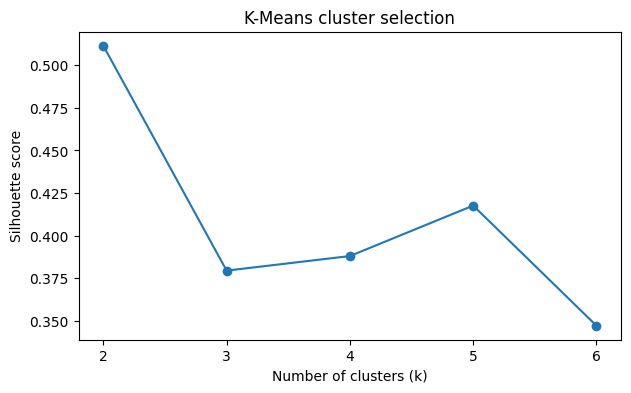

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    k_results_df["k"],
    k_results_df["silhouette"],
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means cluster selection")

plt.xticks(k_results_df["k"])

plt.show()

### 3.6 Final K-Means model

The highest silhouette score among the tested values is obtained with
`k = 2` (silhouette = 0.5114).

I therefore use two clusters for the main model rather than choosing a larger
number simply to create more named archetypes.

The cluster names will be assigned only after inspecting the actual cluster
profiles.

In [12]:
FINAL_K = 2

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

train_clusters = kmeans.fit_predict(X_train)
valid_clusters = kmeans.predict(X_valid)

train_clustered = train_df.copy()
valid_clustered = test_df.copy()

train_clustered["cluster"] = train_clusters
valid_clustered["cluster"] = valid_clusters

print("Training cluster counts:")
display(
    train_clustered["cluster"]
    .value_counts()
    .sort_index()
)

print("\nValidation cluster counts:")
display(
    valid_clustered["cluster"]
    .value_counts()
    .sort_index()
)

Training cluster counts:


,count
cluster,
0,1562
1,13636



Validation cluster counts:


,count
cluster,
0,81
1,12607


In [13]:
profile = (
    train_clustered
    .groupby("cluster")
    .agg(
        n=("content_hash_id", "count"),

        impressions_mean=("gsc_impressions", "mean"),
        impressions_median=("gsc_impressions", "median"),

        clicks_mean=("gsc_clicks", "mean"),
        clicks_median=("gsc_clicks", "median"),

        ctr_mean=("gsc_ctr", "mean"),
        ctr_median=("gsc_ctr", "median"),

        position_mean=("gsc_avg_position", "mean"),
        position_median=("gsc_avg_position", "median"),

        stale_days_mean=("stale_days", "mean"),
        stale_days_median=("stale_days", "median")
    )
    .sort_index()
)

display(
    profile.round(3)
)

,n,impressions_mean,impressions_median,clicks_mean,clicks_median,ctr_mean,ctr_median,position_mean,position_median,stale_days_mean,stale_days_median
cluster,,,,,,,,,,,
0,1562,45.361,3.0,0.168,0.0,0.020,0.0,12.314,6.000,134.280,130.0
1,13636,1257.320,319.0,2.186,0.0,0.002,0.0,16.793,10.864,32.921,34.0


In [14]:
valid_profile = (
    valid_clustered
    .groupby("cluster")
    .agg(
        n=("content_hash_id", "count"),

        impressions_mean=("gsc_impressions", "mean"),
        impressions_median=("gsc_impressions", "median"),

        clicks_mean=("gsc_clicks", "mean"),
        clicks_median=("gsc_clicks", "median"),

        ctr_mean=("gsc_ctr", "mean"),
        ctr_median=("gsc_ctr", "median"),

        position_mean=("gsc_avg_position", "mean"),
        position_median=("gsc_avg_position", "median"),

        stale_days_mean=("stale_days", "mean"),
        stale_days_median=("stale_days", "median")
    )
    .sort_index()
)

display(valid_profile.round(3))

,n,impressions_mean,impressions_median,clicks_mean,clicks_median,ctr_mean,ctr_median,position_mean,position_median,stale_days_mean,stale_days_median
cluster,,,,,,,,,,,
0,81,11.556,4.0,0.049,0.0,0.041,0.0,18.259,7.583,208.901,230.0
1,12607,1371.038,319.0,3.817,0.0,0.002,0.0,13.200,7.333,31.536,34.0


In [15]:
print("Validation cluster distribution by client:")

display(
    pd.crosstab(
        valid_clustered["client_hash_id"],
        valid_clustered["cluster"],
        normalize="index"
    ).round(3)
)

Validation cluster distribution by client:


cluster,0,1
client_hash_id,,
client_3197e6291363b4db,0.001,0.999
client_3f0ce4d44fe94f3d,0.000,1.000
client_73cda7b4e4f265ea,0.007,0.993
client_795153d5b7850ccf,0.004,0.996
client_8dbf3abdf07569e0,0.000,1.000
client_cd12bcfd98942aa1,0.025,0.975
client_fef1a8f436438636,0.000,1.000


### 3.7 Validation of the discovered clusters

The K-Means model was fitted only on the training clients.

I then assigned the held-out clients to their nearest learned cluster
centroids without refitting the model.

I evaluate the resulting validation assignments with the silhouette score
to assess whether the learned structure remains separated on unseen clients.

The validation cluster sizes are also reported because a very small cluster
can be statistically fragile even when its profile is interpretable.

In [16]:
from sklearn.metrics import silhouette_score

validation_silhouette = silhouette_score(
    X_valid,
    valid_clusters
)

print(
    f"Training silhouette: "
    f"{k_results_df.loc[k_results_df['k'] == FINAL_K, 'silhouette'].iloc[0]:.4f}"
)

print(
    f"Validation silhouette: "
    f"{validation_silhouette:.4f}"
)

print("\nValidation cluster proportions:")

validation_proportions = (
    valid_clustered["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .to_frame()
)

display(validation_proportions.round(4))

Training silhouette: 0.5114
Validation silhouette: 0.6875

Validation cluster proportions:


,proportion
cluster,
0,0.0064
1,0.9936


In [17]:
model_vs_baseline = pd.DataFrame([
    {
        "method": "W04 baseline",
        "task": "Action ranking",
        "metric": "Baseline score",
        "value": "See W04 baseline output"
    },
    {
        "method": "W05 K-Means",
        "task": "Content archetype clustering",
        "metric": "Validation silhouette",
        "value": round(validation_silhouette, 4)
    }
])

display(model_vs_baseline)

,method,task,metric,value
0,W04 baseline,Action ranking,Baseline score,See W04 baseline output
1,W05 K-Means,Content archetype clustering,Validation silhouette,0.6875


### 3.8 Comparison with the Week-4 baseline

The Week-4 baseline and the Week-5 K-Means model solve different tasks.

The Week-4 baseline is a hand-written action-ranking rule: it prioritizes
pages that are at least 90 days stale and have at least 1,000 March
impressions.

The Week-5 model is unsupervised: it discovers recurring performance
archetypes without a target label.

Therefore, a common predictive accuracy metric would be misleading. Instead,
I compare them on the same March 2026 validation population by examining how
the baseline's refresh decisions are distributed across the learned
archetypes.

The clustering model is evaluated with silhouette score, while the baseline
retains its original rule-based score.

In [18]:
valid_comparison = valid_clustered.copy()

valid_comparison["baseline_refresh"] = (
    (valid_comparison["stale_days"] >= 90)
    &
    (valid_comparison["gsc_impressions"] >= 1000)
)

valid_comparison["baseline_score"] = np.where(
    valid_comparison["baseline_refresh"],
    valid_comparison["gsc_impressions"],
    0
)

valid_comparison["baseline_action"] = np.where(
    valid_comparison["baseline_refresh"],
    "refresh",
    "monitor"
)

print("Validation rows:", len(valid_comparison))
print(
    "Baseline refresh pages:",
    valid_comparison["baseline_refresh"].sum()
)
print(
    "Baseline refresh rate:",
    round(valid_comparison["baseline_refresh"].mean(), 4)
)

print("\nBaseline actions by K-Means cluster:")

comparison_table = pd.crosstab(
    valid_comparison["cluster"],
    valid_comparison["baseline_action"],
    margins=True
)

display(comparison_table)

Validation rows: 12688
Baseline refresh pages: 0
Baseline refresh rate: 0.0

Baseline actions by K-Means cluster:


baseline_action,monitor,All
cluster,,
0,81,81
1,12607,12607
All,12688,12688


In [19]:
cluster_action_rate = (
    valid_comparison
    .groupby("cluster")
    .agg(
        pages=("content_hash_id", "count"),
        refresh_pages=("baseline_refresh", "sum")
    )
)

cluster_action_rate["refresh_rate"] = (
    cluster_action_rate["refresh_pages"]
    / cluster_action_rate["pages"]
)

display(
    cluster_action_rate.round(4)
)

,pages,refresh_pages,refresh_rate
cluster,,,
0,81,0,0.0
1,12607,0,0.0


In [20]:
model_vs_baseline = pd.DataFrame([
    {
        "method": "W04 baseline",
        "purpose": "Action ranking",
        "evaluation": "March validation refresh rate",
        "result": round(
            valid_comparison["baseline_refresh"].mean(),
            4
        )
    },
    {
        "method": "W05 K-Means",
        "purpose": "Performance archetypes",
        "evaluation": "Validation silhouette",
        "result": round(
            validation_silhouette,
            4
        )
    }
])

display(model_vs_baseline)

,method,purpose,evaluation,result
0,W04 baseline,Action ranking,March validation refresh rate,0.0000
1,W05 K-Means,Performance archetypes,Validation silhouette,0.6875


In [22]:
# W04 baseline coverage on training vs validation clients

train_baseline_refresh = (
    (train_clustered["stale_days"] >= 90)
    &
    (train_clustered["gsc_impressions"] >= 1000)
)

valid_baseline_refresh = (
    (valid_clustered["stale_days"] >= 90)
    &
    (valid_clustered["gsc_impressions"] >= 1000)
)

baseline_coverage = pd.DataFrame([
    {
        "split": "Training clients",
        "pages": len(train_clustered),
        "refresh_pages": int(train_baseline_refresh.sum()),
        "refresh_rate": train_baseline_refresh.mean()
    },
    {
        "split": "Validation clients",
        "pages": len(valid_clustered),
        "refresh_pages": int(valid_baseline_refresh.sum()),
        "refresh_rate": valid_baseline_refresh.mean()
    }
])

display(
    baseline_coverage.round(4)
)

,split,pages,refresh_pages,refresh_rate
0,Training clients,15198,51,0.0034
1,Validation clients,12688,0,0.0000


### 3.8 Model vs Week-4 baseline

The Week-4 baseline and the Week-5 clustering model solve different
problems, so they are not evaluated with a shared predictive metric.

The Week-4 baseline is a hand-written action rule that recommends
`refresh` when a page is both at least 90 days stale and has at least
1,000 impressions.

The Week-5 K-Means model is unsupervised and discovers performance
archetypes. It is evaluated using cluster separation (silhouette score).

For transparency, I report the W04 baseline's coverage on the same
client-held-out split rather than treating its action rate as a model
accuracy metric.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [26]:
# Section 4 — Cluster uncertainty / error analysis

from sklearn.metrics import pairwise_distances

# Distance from each validation page to each learned centroid
valid_distances = pairwise_distances(
    X_valid,
    kmeans.cluster_centers_
)

# Distance to the assigned cluster
valid_clustered["assigned_distance"] = (
    valid_distances[
        np.arange(len(valid_distances)),
        valid_clusters
    ]
)

# Difference between nearest and second-nearest centroid.
# Smaller margin = less clear cluster assignment.
sorted_distances = np.sort(valid_distances, axis=1)

valid_clustered["cluster_margin"] = (
    sorted_distances[:, 1] - sorted_distances[:, 0]
)

print("Most uncertain validation pages:")

display(
    valid_clustered[
        [
            "client_hash_id",
            "content_hash_id",
            "cluster",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_ctr",
            "gsc_avg_position",
            "stale_days",
            "assigned_distance",
            "cluster_margin"
        ]
    ]
    .sort_values("cluster_margin")
    .head(10)
)

Most uncertain validation pages:


,client_hash_id,content_hash_id,cluster,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days,assigned_distance,cluster_margin
25082,client_cd12bcfd98942aa1,content_67652adbebb40260,0,3.0,1.0,0.333333,7.000000,17,9.744587,0.059828
12198,client_3197e6291363b4db,content_9a51a79f693f1f7d,1,4.0,1.0,0.250000,9.500000,14,7.424563,0.155201
12056,client_3197e6291363b4db,content_4685e8ab674a6c03,1,4.0,1.0,0.250000,10.666667,13,7.422232,0.169837
12473,client_73cda7b4e4f265ea,content_9f66d7d0bd7bfba4,1,5.0,1.0,0.200000,11.200000,26,5.979773,0.171102
26881,client_3197e6291363b4db,content_abb8df148cca70b6,1,6.0,1.0,0.166667,5.833333,28,5.074777,0.264157
25184,client_cd12bcfd98942aa1,content_726fa1ee452da49b,1,5.0,1.0,0.200000,7.000000,17,6.018116,0.283519
13248,client_3197e6291363b4db,content_034cffb71ce8f33b,1,7.0,1.0,0.142857,5.250000,33,4.415862,0.302599
13382,client_cd12bcfd98942aa1,content_9a5496694a583150,0,1.0,1.0,1.000000,58.000000,6,28.819514,0.323786
12425,client_3197e6291363b4db,content_f6b1edbea759eb74,1,7.0,1.0,0.142857,5.833333,30,4.410213,0.360944
25976,client_3197e6291363b4db,content_f6d833cad295622c,0,1.0,1.0,1.000000,16.000000,11,28.643146,0.369212


In [27]:
cluster_profile = (
    valid_clustered
    .groupby("cluster")
    .agg(
        n=("content_hash_id", "size"),
        impressions_mean=("gsc_impressions", "mean"),
        impressions_median=("gsc_impressions", "median"),
        clicks_mean=("gsc_clicks", "mean"),
        clicks_median=("gsc_clicks", "median"),
        ctr_mean=("gsc_ctr", "mean"),
        ctr_median=("gsc_ctr", "median"),
        position_mean=("gsc_avg_position", "mean"),
        position_median=("gsc_avg_position", "median"),
        stale_days_mean=("stale_days", "mean"),
        stale_days_median=("stale_days", "median")
    )
)

display(cluster_profile.round(3))

,n,impressions_mean,impressions_median,clicks_mean,clicks_median,ctr_mean,ctr_median,position_mean,position_median,stale_days_mean,stale_days_median
cluster,,,,,,,,,,,
0,81,11.556,4.0,0.049,0.0,0.041,0.0,18.259,7.583,208.901,230.0
1,12607,1371.038,319.0,3.817,0.0,0.002,0.0,13.200,7.333,31.536,34.0


### Cluster interpretation

The final K-Means model produces two performance archetypes.

**Cluster 0 — Stale Low-Demand.** This is a small group of 81 validation
pages (0.64%). These pages have very low search visibility, with a median
of only 4 impressions, and are substantially older than the other cluster
(median staleness of 230 days). Their average position is also weaker.
The group appears to represent pages with both limited demand and high
content age.

**Cluster 1 — Visible / Established.** This cluster contains 12,607 pages
(99.36% of validation). These pages have substantially greater search
visibility (median 319 impressions), better average position, and much
lower staleness (median 34 days). It represents the normal, established
performance population.

The clustering should therefore be treated as a descriptive lens rather
than as ground-truth labels. The clusters describe observed performance
patterns and do not prove that pages belong to intrinsically different
content types.

### Error and uncertainty analysis

Because K-Means is unsupervised, there are no ground-truth labels with
which to calculate classification errors. Instead, uncertainty was
examined using the distance margin between the nearest and second-nearest
cluster centroids.

The least-separated validation pages are mostly very low-volume pages.
Several have only 3–7 impressions and one click. These sparse observations
can sit close to the boundary between archetypes because their performance
signals contain relatively little information.

One particularly clear boundary case has only 3 impressions and 1 click,
with a 0.06 centroid-distance margin. This suggests that the assignment
should not be interpreted as a definitive page label.

The small size of Cluster 0 is also important: only 81 of 12,688
validation pages belong to it. Therefore, the model identifies a narrow
performance pattern rather than two equally common page populations.

### Limitation

The warehouse contains structured performance metrics and content
metadata but not article text. Therefore, these clusters are performance
archetypes, not semantic content clusters. Two pages may be placed in the
same cluster because they behave similarly in search performance even if
their actual topics or content differ substantially.

The validation split is also client-grouped, and the rare Cluster 0 is
much smaller in validation than Cluster 1. Its characteristics should
therefore be interpreted cautiously and monitored on additional clients.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.